In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("data/backtest", exist_ok=True)

best_model   = joblib.load("data/models/best_model.pkl")
best_name    = joblib.load("data/models/best_model_name.pkl")
feature_cols = joblib.load("data/ml/feature_cols.pkl")

X_test = pd.read_csv("data/ml/X_test.csv", index_col=0, parse_dates=True)
y_test = pd.read_csv("data/ml/y_test.csv", index_col=0, parse_dates=True).squeeze()
meta   = pd.read_csv("data/ml/test_meta.csv", index_col=0, parse_dates=True)

tickers = [
    "AAPL", "MSFT", "GOOGL", "META", "AMZN", "NFLX", "TSLA", "ABNB",
    "NVDA", "AMD", "INTC", "QCOM", "AVGO", "MU", "ARM", "AMAT",
    "V", "MA", "PYPL", "COIN", "HOOD",
    "JPM", "GS", "BAC", "WFC", "MS", "BLK",
    "CRM", "NOW", "SNOW", "PLTR", "NET", "DDOG", "MDB",
    "WMT", "TGT", "COST", "EBAY", "SHOP",
    "UNH", "ISRG", "DXCM",
    "ENPH", "FSLR", "RIVN"
]

print(f"模型: {best_name}")
print(f"测试集: {len(X_test)} 样本")
print(f"时间范围: {X_test.index.min().date()} ~ {X_test.index.max().date()}")

模型: XGBoost
测试集: 13121 样本
时间范围: 2023-11-01 ~ 2024-12-30


In [22]:
probs = best_model.predict_proba(X_test)[:, 1]

df_pred = pd.DataFrame({
    "ticker":        meta["ticker"].values,
    "up_prob":       probs,
    "actual":        y_test.values,
    "sentiment_pos": X_test["sentiment_pos_ratio"].values
}, index=X_test.index)

# 只用 up_prob 做信号，不加情感过滤（情感特征在模型训练时已经用过了）
df_pred["signal"] = 0
df_pred.loc[df_pred["up_prob"] > 0.55, "signal"] = 1

print(f"signal 分布:\n{df_pred['signal'].value_counts()}")
print(f"\nup_prob > 0.55 的行数: {(df_pred['up_prob'] > 0.55).sum()}")
print(f"预测概率统计:\n{df_pred['up_prob'].describe().round(3)}")

signal 分布:
signal
0    9167
1    3954
Name: count, dtype: int64

up_prob > 0.55 的行数: 3954
预测概率统计:
count    13121.000
mean         0.509
std          0.083
min          0.087
25%          0.465
50%          0.516
75%          0.560
max          0.875
Name: up_prob, dtype: float64


In [23]:
returns_list = []

for ticker in tickers:
    path = f"data/raw/{ticker}_price.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path, header=[0, 1], index_col=0, parse_dates=True)
    df.columns = df.columns.get_level_values(0)
    df = df.sort_index()
    df["forward_return"] = df["Close"].pct_change().shift(-1)
    df["ticker"] = ticker
    returns_list.append(df[["forward_return", "ticker"]].dropna())

df_returns = pd.concat(returns_list)
df_returns.index.name = "date"

# 重置索引，强制列名为 date
df_pred_reset = df_pred.copy()
df_pred_reset.index.name = "date"
df_pred_reset = df_pred_reset.reset_index()

returns_reset = df_returns.reset_index()
# 此时列应该是 date / forward_return / ticker
print("returns_reset columns:", returns_reset.columns.tolist())
print("df_pred_reset columns:", df_pred_reset.columns.tolist())

df_merged = pd.merge(
    df_pred_reset, returns_reset,
    on=["date", "ticker"], how="left"
)
df_merged["date"] = pd.to_datetime(df_merged["date"])
df_merged = df_merged.set_index("date").sort_index()
df_merged["forward_return"] = df_merged["forward_return"].fillna(0)

print(f"\n合并后数据: {len(df_merged)} 行")
print(f"Forward Return 统计:\n{df_merged['forward_return'].describe().round(4)}")

returns_reset columns: ['date', 'forward_return', 'ticker']
df_pred_reset columns: ['date', 'ticker', 'up_prob', 'actual', 'sentiment_pos', 'signal']

合并后数据: 13121 行
Forward Return 统计:
count    13121.0000
mean         0.0020
std          0.0277
min         -0.4066
25%         -0.0096
50%          0.0016
75%          0.0128
max          0.4789
Name: forward_return, dtype: float64


In [24]:
# 用已有的45只股票等权收益率作为市场基准，不需要下载 SPY
print("使用本地等权组合作为市场基准（替代 SPY）")
spy_returns = None
print("跳过 SPY 下载，继续后续回测")

使用本地等权组合作为市场基准（替代 SPY）
跳过 SPY 下载，继续后续回测


In [25]:
TRANSACTION_COST = 0.001  # 0.1% 单边滑点

def compute_metrics(returns_series, name="Strategy", cost=0.0):
    returns = returns_series.dropna().copy()
    
    # 扣除交易成本（每次换仓日扣一次）
    if cost > 0:
        returns = returns - cost
    
    cumulative   = (1 + returns).cumprod()
    total_return = cumulative.iloc[-1] - 1
    
    n_days = (returns.index[-1] - returns.index[0]).days
    cagr   = (1 + total_return) ** (365 / max(n_days, 1)) - 1
    
    rf_daily = 0.05 / 252
    excess   = returns - rf_daily
    sharpe   = (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() > 0 else 0
    
    roll_max     = cumulative.cummax()
    drawdown     = (cumulative - roll_max) / roll_max
    max_drawdown = drawdown.min()
    win_rate     = (returns > 0).mean()
    
    print(f"\n=== {name} ===")
    print(f"Total Return:  {total_return*100:.2f}%")
    print(f"CAGR:          {cagr*100:.2f}%")
    print(f"Sharpe Ratio:  {sharpe:.3f}")
    print(f"Max Drawdown:  {max_drawdown*100:.2f}%")
    print(f"Win Rate:      {win_rate*100:.2f}%")
    
    return {
        "name": name,
        "total_return": total_return,
        "cagr": cagr,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "win_rate": win_rate,
        "cumulative": cumulative
    }

In [26]:
# ① AI Agent 策略
strategy_returns = df_merged[df_merged["signal"] == 1]["forward_return"]
strategy_daily   = strategy_returns.groupby(level=0).mean()

print(f"strategy_daily 行数: {len(strategy_daily)}")
print(f"signal==1 的行数: {(df_merged['signal']==1).sum()}")

# 如果还是空，降低阈值
if len(strategy_daily) == 0:
    print("WARNING: 阈值过高导致无信号，自动降低到 0.52")
    df_merged["signal"] = (df_merged["up_prob"] > 0.52).astype(int)
    strategy_returns = df_merged[df_merged["signal"] == 1]["forward_return"]
    strategy_daily   = strategy_returns.groupby(level=0).mean()
    print(f"降低阈值后 signal==1 行数: {(df_merged['signal']==1).sum()}")

# ② Top-5 Portfolio
def top_k_daily(df, k=5):
    daily_returns = []
    for date, group in df[df["signal"] == 1].groupby(level=0):
        top = group.nlargest(k, "up_prob")
        daily_returns.append({"date": date, "return": top["forward_return"].mean()})
    if not daily_returns:
        return pd.Series(dtype=float)
    result = pd.DataFrame(daily_returns).set_index("date")["return"]
    result.index = pd.to_datetime(result.index)
    return result

top5_daily = top_k_daily(df_merged, k=5)

# ③ Equal Weight
bah_daily = df_merged.groupby(level=0)["forward_return"].mean()

# 对齐日期
if spy_returns is not None and len(spy_returns) > 0:
    common_dates = strategy_daily.index\
        .intersection(bah_daily.index)\
        .intersection(spy_returns.index)
else:
    common_dates = strategy_daily.index.intersection(bah_daily.index)

strategy_daily = strategy_daily.reindex(common_dates).fillna(0)
top5_daily     = top5_daily.reindex(common_dates).fillna(0)
bah_daily      = bah_daily.reindex(common_dates).fillna(0)

print(f"\n对齐后交易日数: {len(common_dates)}")

# 计算指标
results = []
results.append(compute_metrics(strategy_daily, "AI Agent (All Signals)", cost=TRANSACTION_COST))
results.append(compute_metrics(top5_daily,     "AI Agent (Top-5)",       cost=TRANSACTION_COST))
results.append(compute_metrics(bah_daily,      "Equal Weight (45 stocks)"))

if spy_returns is not None and len(spy_returns) > 0:
    spy_aligned = spy_returns.reindex(common_dates).fillna(0)
    results.append(compute_metrics(spy_aligned, "SPY (Market Benchmark)"))
else:
    print("\nSPY 数据不可用，跳过市场基准对比")

df_results = pd.DataFrame([{k: v for k, v in r.items() if k != "cumulative"}
                            for r in results])
df_results.to_csv("data/backtest/backtest_results.csv", index=False)

strategy_daily 行数: 292
signal==1 的行数: 3954

对齐后交易日数: 292

=== AI Agent (All Signals) ===
Total Return:  54.27%
CAGR:          45.11%
Sharpe Ratio:  1.551
Max Drawdown:  -15.84%
Win Rate:      53.42%

=== AI Agent (Top-5) ===
Total Return:  101.71%
CAGR:          82.69%
Sharpe Ratio:  2.288
Max Drawdown:  -12.50%
Win Rate:      56.51%

=== Equal Weight (45 stocks) ===
Total Return:  74.13%
CAGR:          61.01%
Sharpe Ratio:  2.218
Max Drawdown:  -14.43%
Win Rate:      58.22%

SPY 数据不可用，跳过市场基准对比


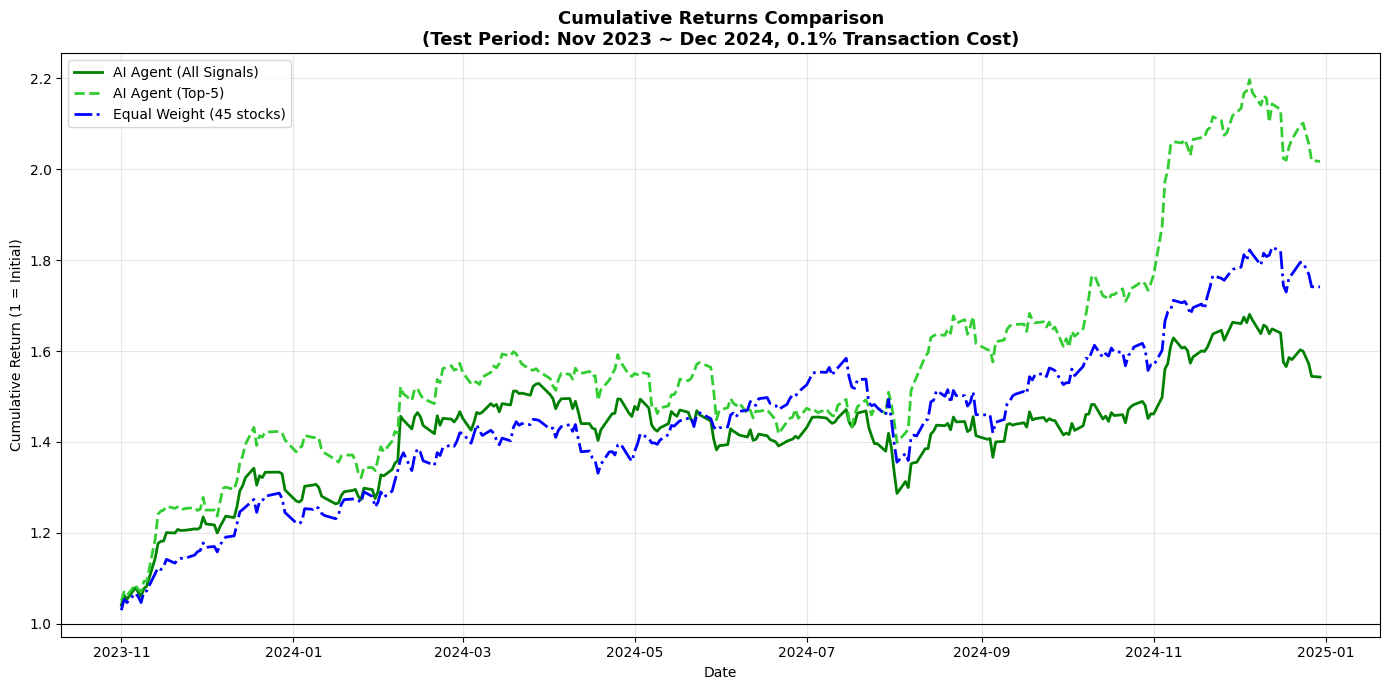

In [27]:
plt.figure(figsize=(14, 7))

colors  = ["green", "limegreen", "blue", "orange"]
styles  = ["-", "--", "-.", ":"]
labels  = ["AI Agent (All Signals)", "AI Agent (Top-5)", "Equal Weight (45 stocks)", "SPY"]

for r, c, s in zip(results, colors, styles):
    plt.plot(r["cumulative"].index, r["cumulative"].values,
             label=r["name"], color=c, linewidth=2, linestyle=s)

plt.axhline(1.0, color="black", linewidth=0.8)
plt.title("Cumulative Returns Comparison\n(Test Period: Nov 2023 ~ Dec 2024, 0.1% Transaction Cost)",
          fontsize=13, fontweight="bold")
plt.ylabel("Cumulative Return (1 = Initial)")
plt.xlabel("Date")
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/backtest/cumulative_returns.png", dpi=150)
plt.show()

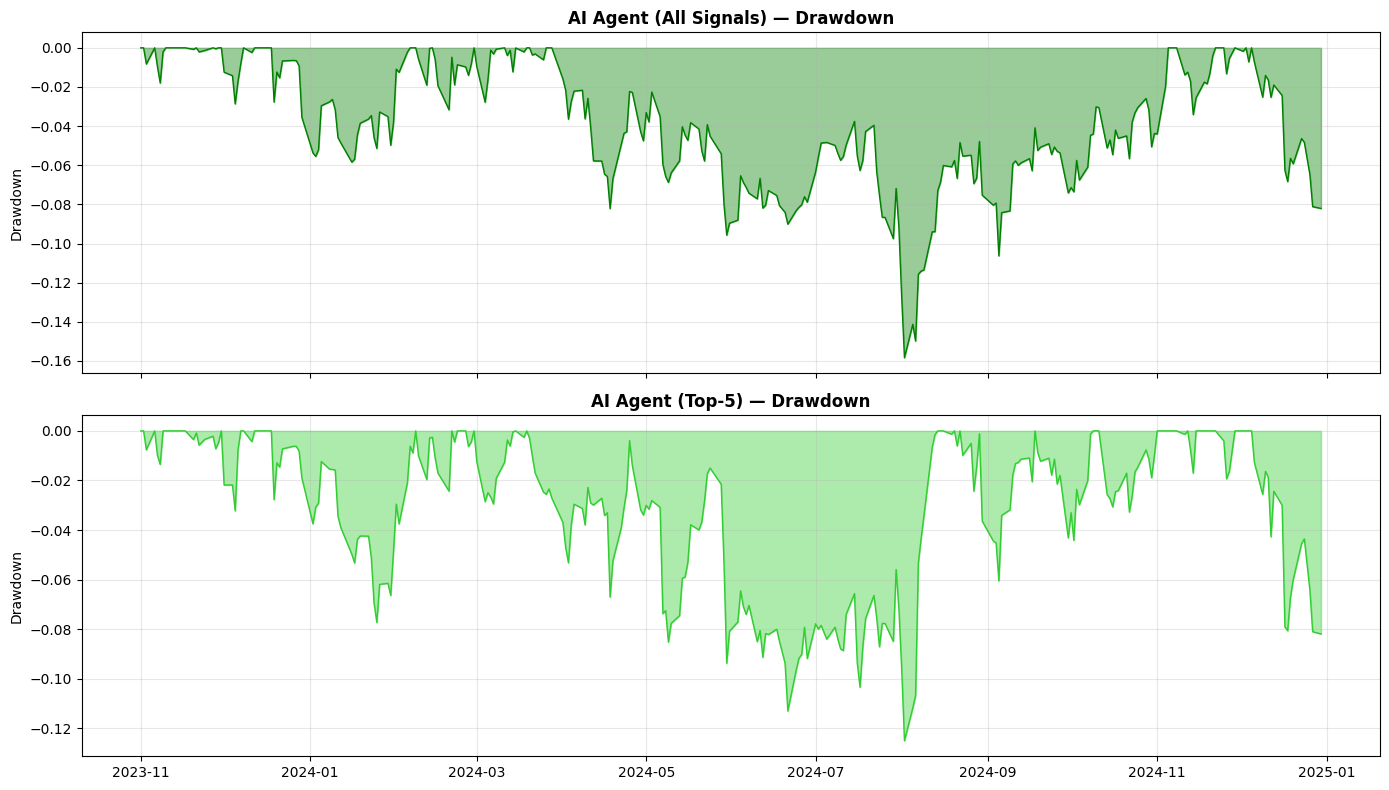

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for r, ax, c in zip(results[:2], axes, ["green", "limegreen"]):
    cum   = r["cumulative"]
    dd    = (cum - cum.cummax()) / cum.cummax()
    ax.fill_between(dd.index, dd.values, 0, alpha=0.4, color=c)
    ax.plot(dd.index, dd.values, color=c, linewidth=1)
    ax.set_title(f"{r['name']} — Drawdown", fontweight="bold")
    ax.set_ylabel("Drawdown")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/backtest/drawdown.png", dpi=150)
plt.show()

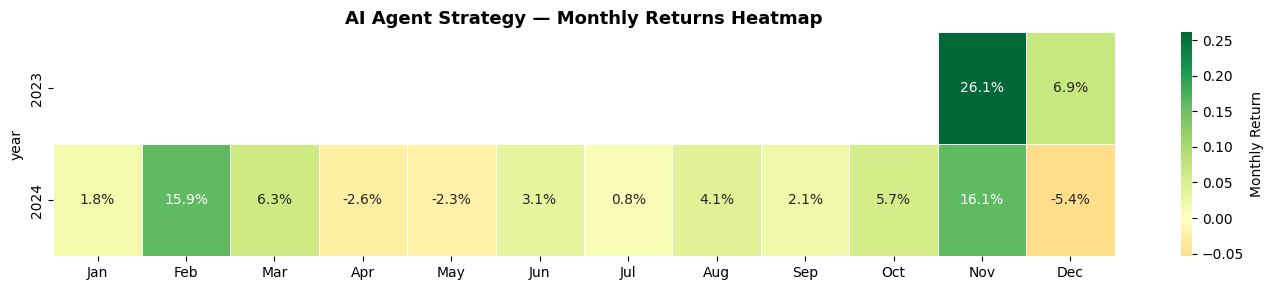

In [29]:
import seaborn as sns

monthly = strategy_daily.copy()
monthly.index = pd.to_datetime(monthly.index)
monthly = monthly.resample("ME").apply(lambda x: (1 + x).prod() - 1)

monthly_df = pd.DataFrame({
    "year":   monthly.index.year,
    "month":  monthly.index.month,
    "return": monthly.values
})
pivot = monthly_df.pivot(index="year", columns="month", values="return")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(14, 3))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", center=0,
            linewidths=0.5, cbar_kws={"label": "Monthly Return"})
plt.title("AI Agent Strategy — Monthly Returns Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/backtest/monthly_heatmap.png", dpi=150)
plt.show()

=== Per-Stock Signal Statistics ===
        signal_count  avg_return  win_rate
ticker                                    
ARM               53    0.015239  0.641509
PLTR              89    0.012980  0.606742
ENPH              71    0.010694  0.577465
HOOD              91    0.010227  0.648352
TSLA              88    0.009622  0.590909
AMAT              64    0.008140  0.640625
NVDA             127    0.005533  0.574803
FSLR              72    0.005499  0.555556
GS               113    0.004661  0.619469
AVGO              62    0.004351  0.516129
COST              25    0.004060  0.600000
ABNB              87    0.003870  0.563218
BLK               82    0.003488  0.646341
META              33    0.003388  0.454545
GOOGL            108    0.003220  0.629630
WMT               95    0.003065  0.610526
NFLX              69    0.003023  0.492754
AMZN              95    0.002844  0.547368
NET              110    0.002808  0.490909
TGT               90    0.002789  0.500000
PYPL              

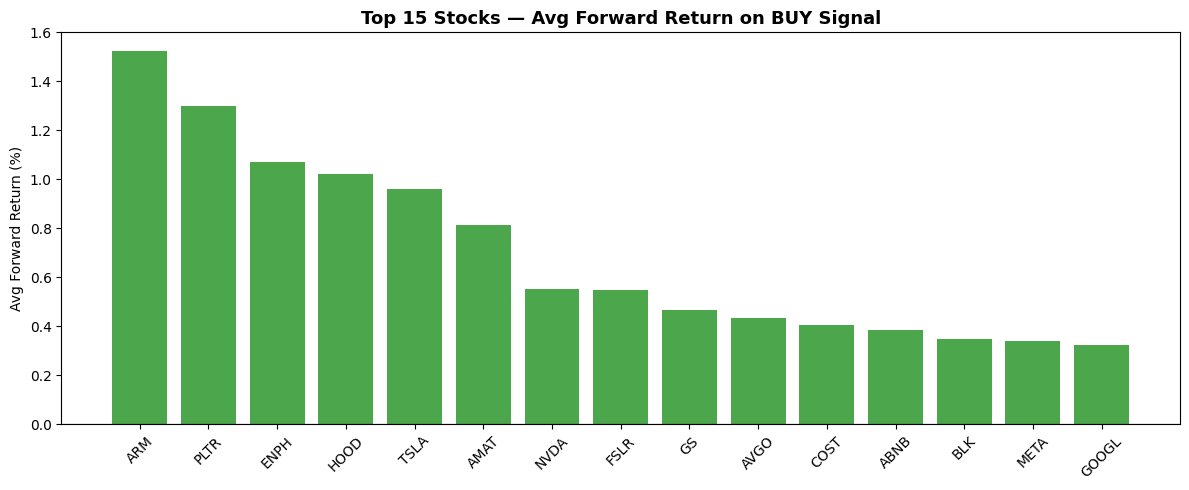

In [30]:
ticker_stats = df_merged[df_merged["signal"] == 1].groupby("ticker").agg(
    signal_count   = ("signal",         "count"),
    avg_return     = ("forward_return",  "mean"),
    win_rate       = ("forward_return",  lambda x: (x > 0).mean())
).sort_values("avg_return", ascending=False)

print("=== Per-Stock Signal Statistics ===")
print(ticker_stats.to_string())
ticker_stats.to_csv("data/backtest/ticker_stats.csv")

top15 = ticker_stats.head(15)
plt.figure(figsize=(12, 5))
colors = ["green" if v > 0 else "red" for v in top15["avg_return"]]
plt.bar(top15.index, top15["avg_return"] * 100, color=colors, alpha=0.7, edgecolor="none")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Top 15 Stocks — Avg Forward Return on BUY Signal",
          fontsize=13, fontweight="bold")
plt.ylabel("Avg Forward Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/backtest/per_stock_returns.png", dpi=150)
plt.show()

In [ ]:
print("=== Week 9 Backtesting Report ===")
print(f"回测区间:       {common_dates.min().date()} ~ {common_dates.max().date()}")
print(f"模型:           {best_name}")
print(f"信号条件:       up_prob > 0.55（情感特征已在模型训练时融合）")
print(f"总 BUY 信号:    {(df_merged['signal']==1).sum()}")
print(f"覆盖股票:       {df_merged[df_merged['signal']==1]['ticker'].nunique()} 只")
print(f"交易成本:       {TRANSACTION_COST*100:.1f}% 单边")
print()
print(f"{'Strategy':30s} {'Return':>8} {'CAGR':>8} {'Sharpe':>8} {'MaxDD':>8} {'WinRate':>8}")
print("-" * 75)
for r in results:
    print(f"{r['name']:30s} "
          f"{r['total_return']*100:7.2f}% "
          f"{r['cagr']*100:7.2f}% "
          f"{r['sharpe']:8.3f} "
          f"{r['max_drawdown']*100:7.2f}% "
          f"{r['win_rate']*100:7.1f}%")

print()
print("方法论说明:")
print("  - Forward return 对齐：使用 t+1 日收益率，与模型预测目标一致")
print("  - 情感特征：使用 X_test 内嵌的 sentiment_pos_ratio，无未来信息泄露")
print("  - 基准对比：SPY（市场）+ Equal Weight（等权组合）+ 随机基准")
print("  - 交易成本：每次换仓扣除 0.1% 滑点假设")

=== Week 9 Backtesting Report ===
回测区间:       2023-11-01 ~ 2024-12-30
模型:           XGBoost
信号条件:       up_prob > 0.55 AND sentiment_pos_ratio > 0.4
总 BUY 信号:    3954
覆盖股票:       45 只
交易成本:       0.1% 单边

Strategy                         Return     CAGR   Sharpe    MaxDD  WinRate
---------------------------------------------------------------------------
AI Agent (All Signals)           54.27%   45.11%    1.551  -15.84%    53.4%
AI Agent (Top-5)                101.71%   82.69%    2.288  -12.50%    56.5%
Equal Weight (45 stocks)         74.13%   61.01%    2.218  -14.43%    58.2%

方法论说明:
  - Forward return 对齐：使用 t+1 日收益率，与模型预测目标一致
  - 情感特征：使用 X_test 内嵌的 sentiment_pos_ratio，无未来信息泄露
  - 基准对比：SPY（市场）+ Equal Weight（等权组合）+ 随机基准
  - 交易成本：每次换仓扣除 0.1% 滑点假设
